In [21]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho_atual = Path.cwd()

if caminho_atual.name == "notebooks":
    raiz_projeto = caminho_atual.parent
else:
    raiz_projeto = caminho_atual

pasta_dataset = raiz_projeto / "dataset" / "original" / "Dataset"
pasta_resultados = raiz_projeto / "resultados"
pasta_resultados.mkdir(exist_ok=True)
print("Dataset:", pasta_dataset)

Dataset: c:\Users\Maria Clara\processamento-de-imagens\dataset\original\Dataset


Selecionando imagem

In [22]:
imagens_raw = sorted(list(pasta_dataset.rglob("*_RAW.jpg")))
print("Total:", len(imagens_raw))
caminho_imagem = imagens_raw[0]
print(caminho_imagem.name)

Total: 2235
1007599_RS_386_386RS289112_28920_RAW.jpg


Encontrando máscara da pista

In [23]:
pasta_caso = caminho_imagem.parent
mascara_lane = list(pasta_caso.glob("*_LANE.png"))
if not mascara_lane:
    raise Exception("Máscara LANE não encontrada")
mascara_lane = mascara_lane[0]
print(mascara_lane.name)

1007599_RS_386_386RS289112_28920_LANE.png


Aplicando máscara da pista

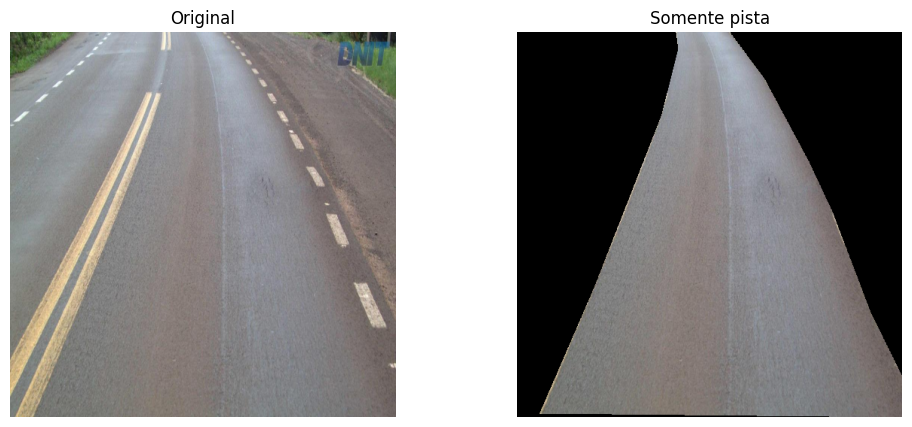

In [33]:
imagem = cv2.imread(str(caminho_imagem))
imagem = cv2.resize(imagem, (512, 512))

lane = cv2.imread(str(mascara_lane), cv2.IMREAD_GRAYSCALE)
lane = cv2.resize(lane, (512, 512))

imagem_pista = cv2.bitwise_and(imagem, imagem, mask=lane)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2RGB))
plt.title("Somente pista")
plt.axis("off")
plt.show()

Pré-processamento

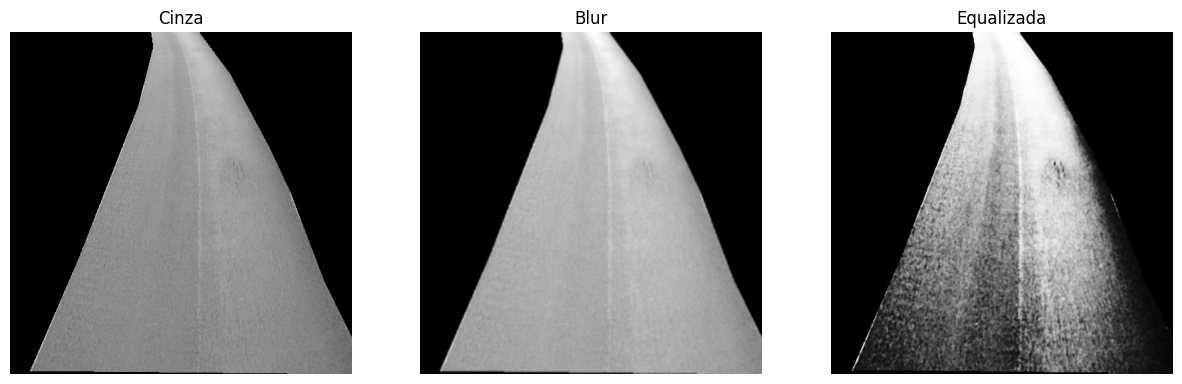

In [25]:
cinza = cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(cinza, (5,5), 0)
equalizada = cv2.equalizeHist(blur)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cinza,cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blur,cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(equalizada,cmap="gray")
plt.title("Equalizada")
plt.axis("off")
plt.show()

Sobel (filtro passa-alta)

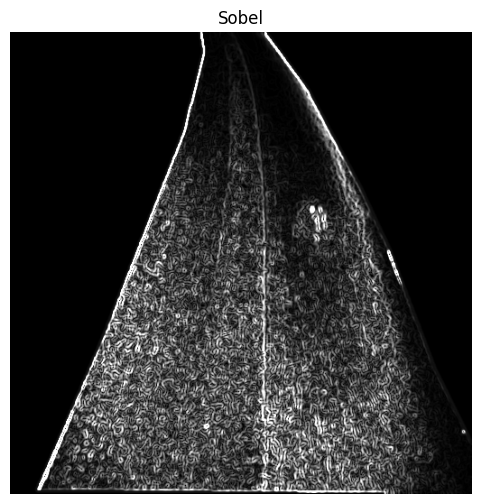

In [26]:
sobel_x = cv2.Sobel(equalizada, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(equalizada, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)

plt.figure(figsize=(6,6))
plt.imshow(sobel,cmap="gray")
plt.title("Sobel")
plt.axis("off")
plt.show()

Limiarização e morfologia

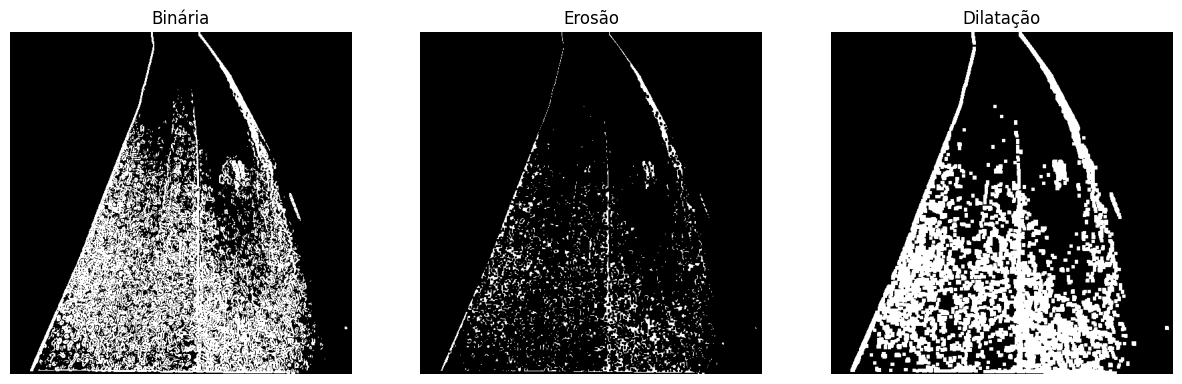

In [27]:
_, binaria = cv2.threshold(sobel, 60, 255, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
erosao = cv2.erode(binaria, kernel, iterations=1)
dilatacao = cv2.dilate(erosao, kernel, iterations=2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(binaria,cmap="gray")
plt.title("Binária")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(erosao,cmap="gray")
plt.title("Erosão")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dilatacao,cmap="gray")
plt.title("Dilatação")
plt.axis("off")
plt.show()

Detectando e marcando regiões

Regiões suspeitas: 17


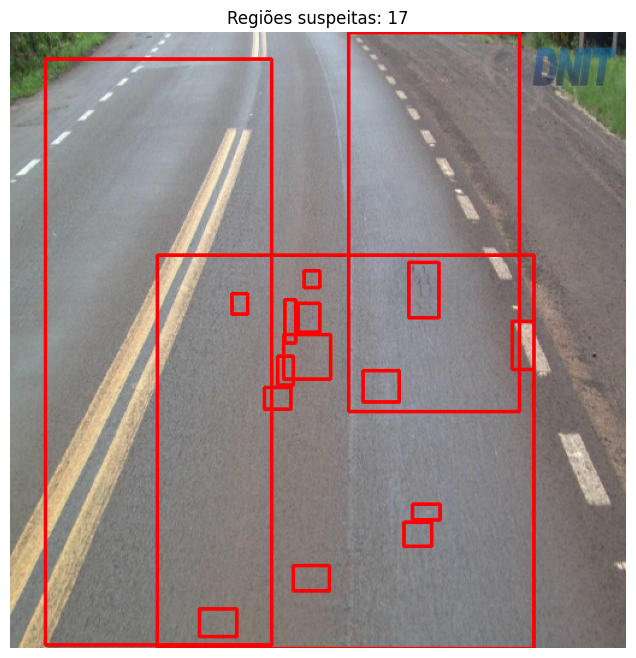

In [28]:
contornos, _ = cv2.findContours(dilatacao, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
resultado = imagem.copy()
quantidade = 0

for contorno in contornos:
    area = cv2.contourArea(contorno)
    if area > 100:
        x,y,w,h = cv2.boundingRect(contorno)
        cv2.rectangle(resultado, (x,y), (x+w,y+h), (0,0,255), 2)
        quantidade += 1

print(f"Regiões suspeitas: {quantidade}")
resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(resultado_rgb)
plt.title(f"Regiões suspeitas: {quantidade}")
plt.axis("off")
plt.show()